In [1]:
#%config InlineBackend.figure_formats=['svg']
from os import listdir
import numpy as np

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.clustering.kernelDensity import kernel_density
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from AutoencoderAPI.utils.clustering.GaussianMixture import gaussian_mixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

In [2]:
signal_size = 30_000
certain_clusters = 3
selected_dB = [10.59, 11.25, 12.04, 13.0, 14.24, 15.99, 18.97]#[9.05,  9.5, 10.01, 10.59, 11.25, 12.04, 13.0, 14.24, 15.99, 18.97]
skip = 2
path_dB = 'Datasets/SNSPD/Paderborn/db_shuffled.npy'
path_test = 'Datasets/SNSPD/Paderborn/data test/'
path_train = 'Datasets/SNSPD/Paderborn/data train/'
path_model = 'grid-search-SNSPD param 4/run 09/fold 0'#'run-2024-01-28-00-27/fold 0'#
path_save = f"MetricLog/Metric_SNSPD_{'all'}dB_skip{skip}"
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = []
X_train = []
number_file_test = len(listdir(path_test)) 
number_file_train = len(listdir(path_train))
dB = np.load(path_dB)

for file_number in range(number_file_test)[::2]:
    
    if dB[file_number] in selected_dB:
        data_temp = np.load(f"{path_test}/TracesNr{file_number}.npy").reshape(-1,signal_size)
        data_temp = data_temp[:, 3250:4250]
        data_temp = data_temp[:, ::skip]
        data_temp = data_temp[::5]
        #data_temp = data_temp[:, 1]
    
        X_test.append(data_temp)

for file_number in range(number_file_test, number_file_train)[::2]:
    
    if dB[file_number] in selected_dB:
        data_temp = np.load(f"{path_train}/TracesNr{file_number}.npy").reshape(-1,signal_size)
        data_temp = data_temp[:, 3250:4250]
        data_temp = data_temp[:, ::skip]
        data_temp = data_temp[::5]
        #data_temp = data_temp[:, 1]

        X_train.append(data_temp)

X_train = -1*np.concatenate(X_train)#.reshape(-1,1)
X_train = (X_train - mean)/std
#X_train = X_train[np.min(X_train, axis=1) < -0.55]
X_train = X_train[np.max(X_train, axis=1) > 0]

X_test = -1*np.concatenate(X_test)#.reshape(-1,1)
X_test = (X_test - mean)/std
#X_test = X_test[np.min(X_test, axis=1) < -0.55]
#X_test_zeros = X_test[np.max(X_test, axis=1) < 0]
X_test = X_test[np.max(X_test, axis=1) > 0]

#zeros = len(X_test_zeros)

8287.182046417778 18042.082022959665


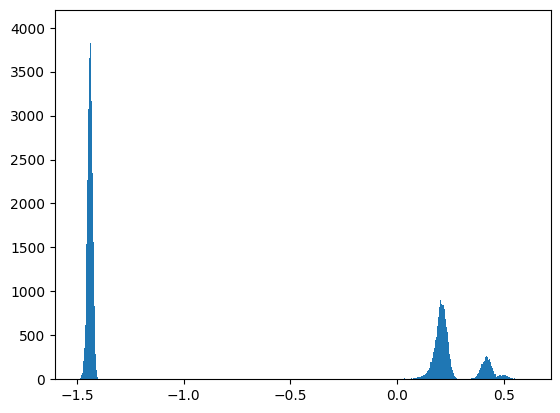

In [ ]:
import matplotlib.pyplot as plt
plt.hist(X_train, bins=1000)
plt.show()

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/uniformMixture.py:91: RuntimeWarning: divide by zero encountered in log
  sum1 = np.log(np.sum(self.get_probability(X), axis = 0))


  0%|          | 0/100 [00:00<?, ?it/s]

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/uniformMixture.py:82: RuntimeWarning: invalid value encountered in divide
  self.mu = np.sum(self.gamma * X, axis = 0) / N_k


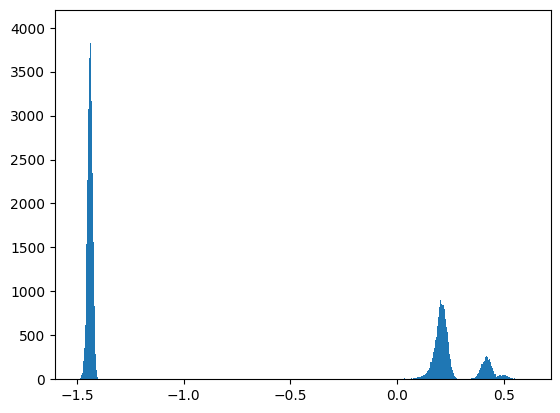

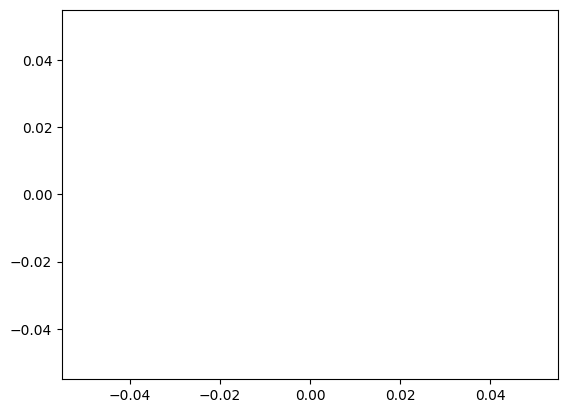

In [4]:
from AutoencoderAPI.utils.clustering.uniformMixture import UMM_1D

uni = UMM_1D(mean_init = [-1.5, 0, 0.5], 
             n_cluster = 3, 
             n_step = 100)
uni.fit(X_train)


  0%|          | 0/100 [00:00<?, ?it/s]

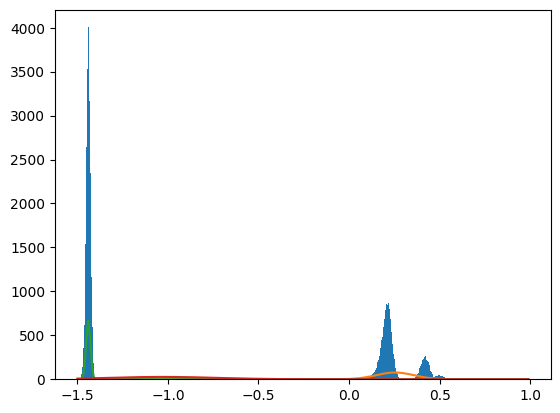

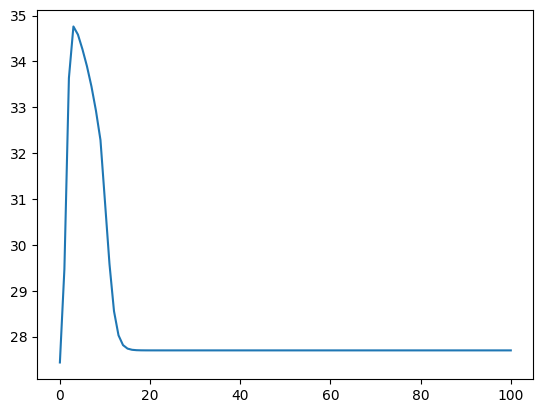

In [5]:
from AutoencoderAPI.utils.clustering.customGaussianMixture import GMM_1D

uni = GMM_1D(#mean_init = [-1.5, 0, 0.5], 
             n_cluster = 3, 
             n_step = 100)
uni.fit(X_train)

  0%|          | 0/100 [00:00<?, ?it/s]

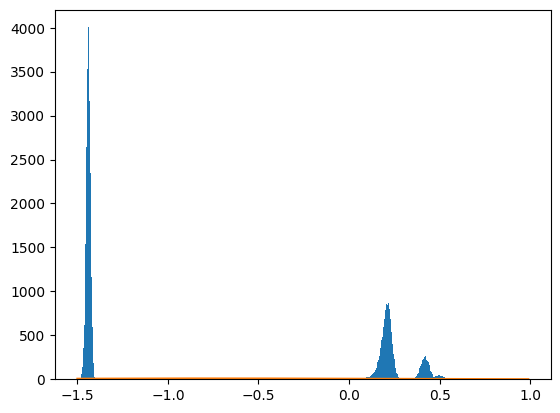

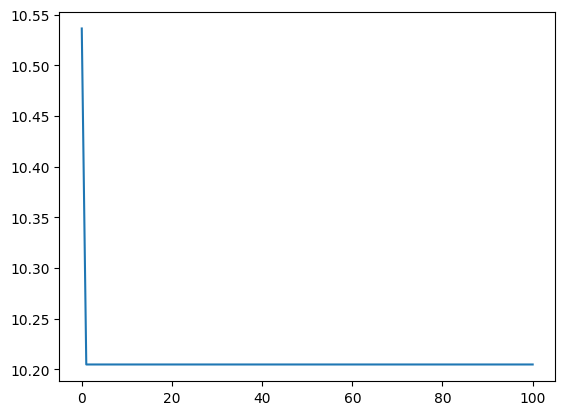

In [10]:
from AutoencoderAPI.utils.clustering.customMultiGaussianMixture import MGMM_1D

uni = MGMM_1D(mean_init = [-1.5, 0, 0.5],
              n_cluster = 1, 
              n_step = 100)
uni.fit(X_train)

  0%|          | 0/100 [00:00<?, ?it/s]

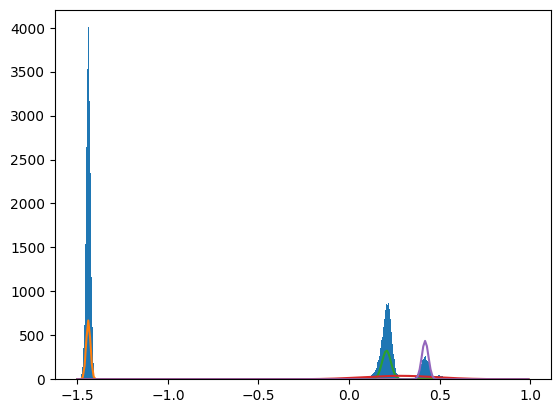

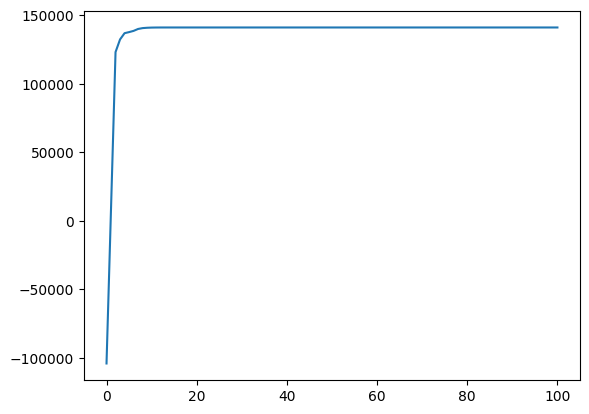

[0.375  0.375  0.1875 0.0625] 0.6246655531808318


In [16]:
from AutoencoderAPI.utils.clustering.poissonGaussianMixture import PGMM_1D

uni = PGMM_1D(mean_init = [-1.5,0, 0.2, 0.5], 
             n_cluster = 4, 
             n_step = 100)
uni.fit(X_train)

data = np.concatenate([np.ones(int(1000*weight)) * value for weight, value in zip(uni.pi, np.arange(3))])
mean = np.mean(data)
variance = np.var(data)
print(uni.pi, variance/mean**2 + 1 - 1/mean)


In [27]:

signal_size = 30_000
certain_clusters = 3
path_test = 'Datasets/SNSPD/Paderborn/data test/'
path_train = 'Datasets/SNSPD/Paderborn/data train/'
path_model = 'grid-search-SNSPD param 4/run 09/fold 0'
path_save = 'MetricLog/test'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = -1 * np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::5, 3250:4250] for fileName in listdir(path_test)])#[::2]
X_train = -1 * np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::5, 3250:4250] for fileName in listdir(path_train)])

X_test = (X_test - mean) / std
X_train = (X_train - mean) / std

#init_len = len(X_test)
#X_test = X_test[np.min(X_test, axis=1) < -0.5]

X_train = X_train[np.max(X_train, axis=1) > 0]
X_test = X_test[np.max(X_test, axis=1) > 0]
#X_train = X_train[np.min(X_train, axis=1) < -1.6]
#X_test = X_test[np.min(X_test, axis=1) <  -1.6]

#zeros = init_len - len(X_test)
#X_train = X_train[:, 3250:4250]
#index_max_var = np.argmax(np.var(X_train, axis=0))
#index_max_var = np.argpartition(np.var(X_train, axis=0), -10)[-10:]
#X_train = X_train[:, index_max_var]
#X_test = X_test[:, index_max_var]


8287.182046417778 18042.082022959665


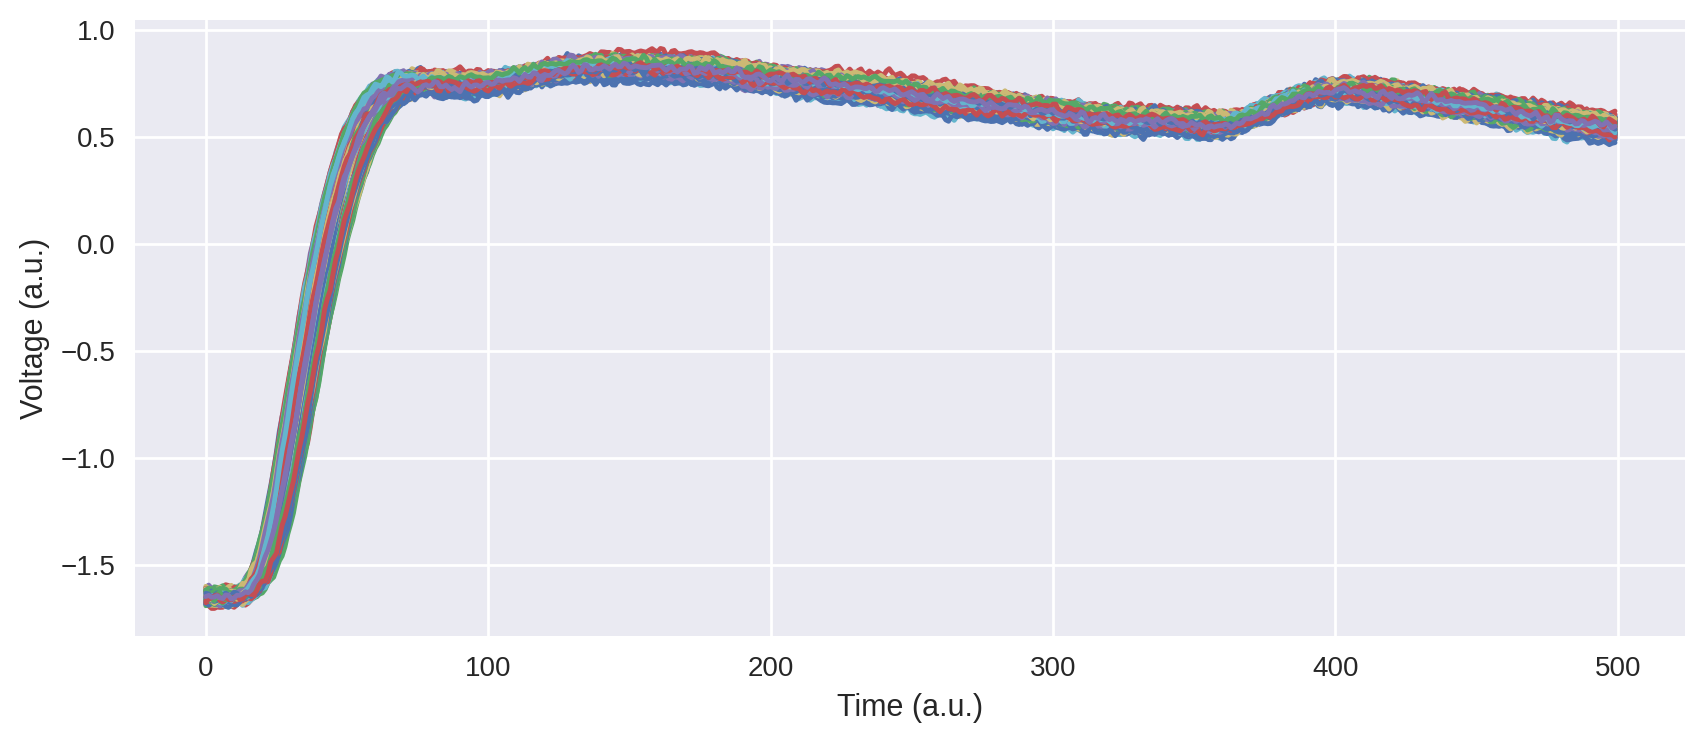

In [46]:
plot_traces(np.copy(X_test))

### Max Variance Value

In [3]:
index_max_var = np.argpartition(np.var(X_train, axis=0), -1)[-1:]
#X_train = X_train[:, index_max_var]
X_i_MAX = X_test[:, index_max_var]
X_l_MAX = X_test[:, index_max_var]

#X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X_test), filter=True)

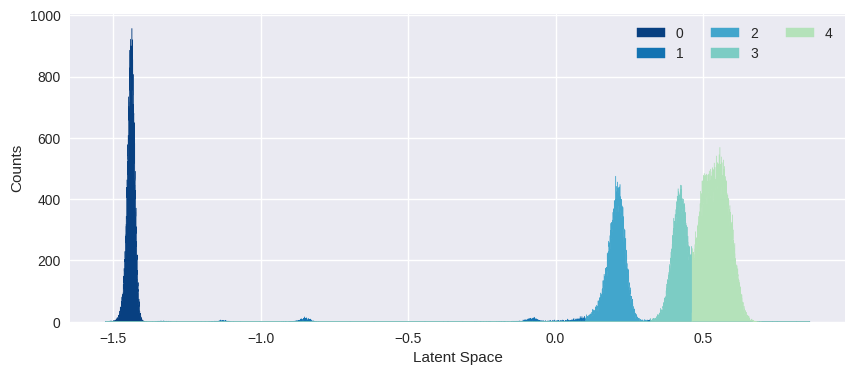

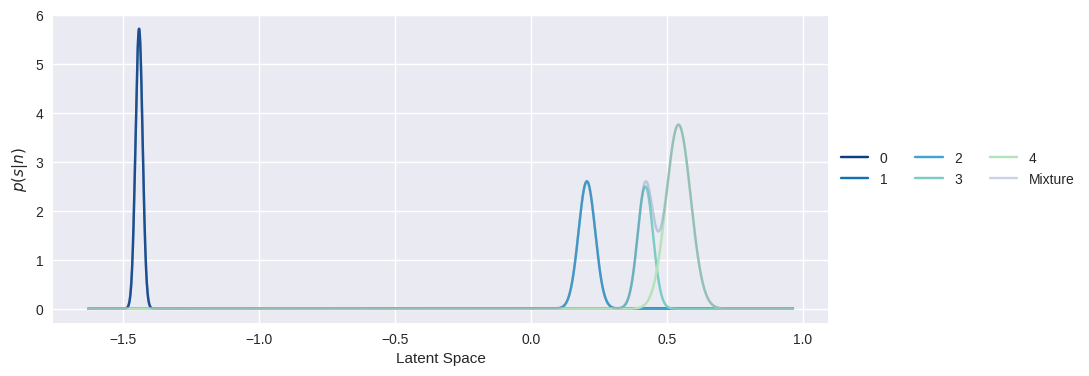

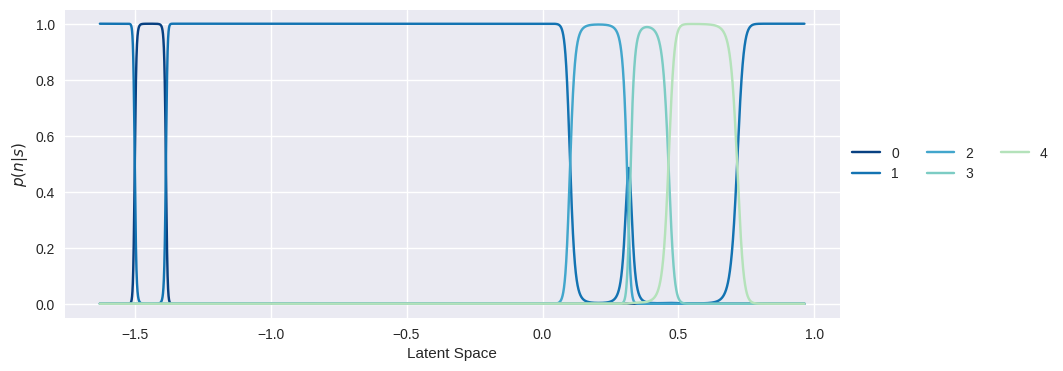

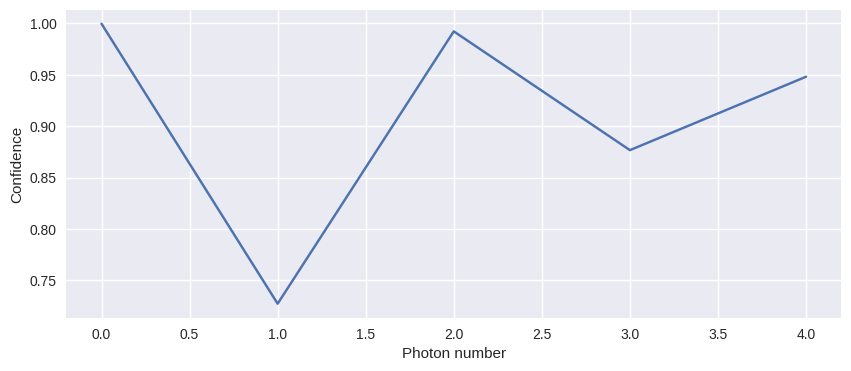

In [15]:
kd = gaussian_mixture(X_l_MAX, 
                    number_cluster=5,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

X_l_MAX = kd.normalize_latent(X_l_MAX, certain_clusters)

### Area

In [31]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X_test), filter=False, threshold_cst=-2)

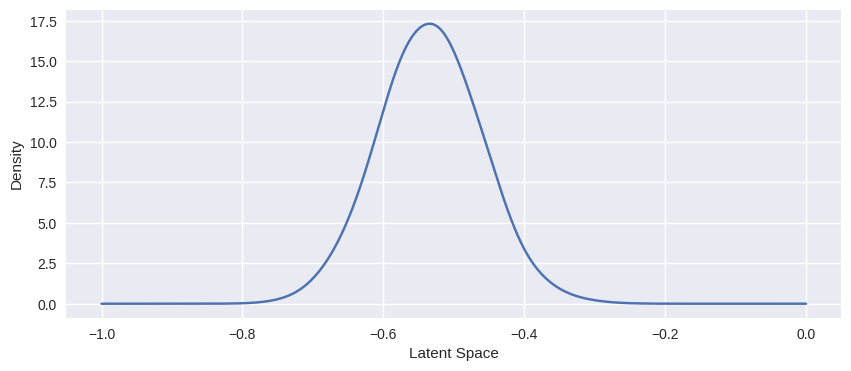

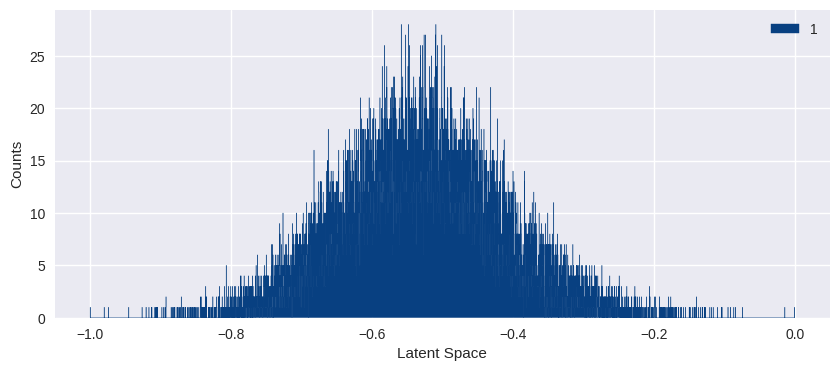

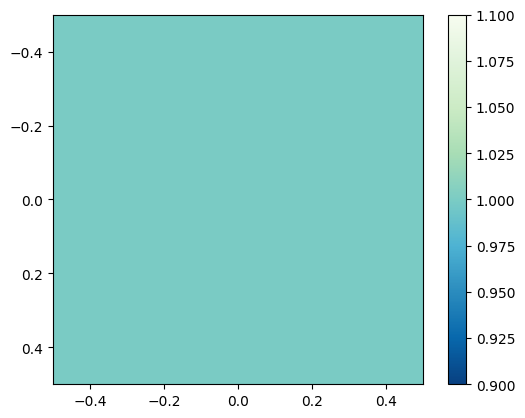

In [ ]:
kd = density_gaussianMixture(X_l_AREA, 
                                bw = [0.0268], 
                                min_cluster_prob = 0.1,
                                bins_plot = 5000,
                                flip = True, 
                                skip = 1)
kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AREA = kd.normalize_latent(X_l_AREA, certain_clusters)

### Principal Component Analysis (PCA)

In [8]:
X_i_PCA, X_l_PCA = dimension_reduction(np.copy(X_test),np.copy(X_test), path_save, PCA, n_components=1) 

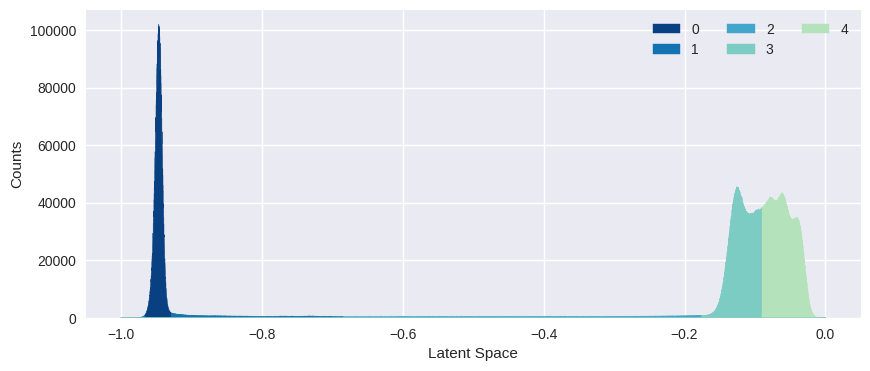

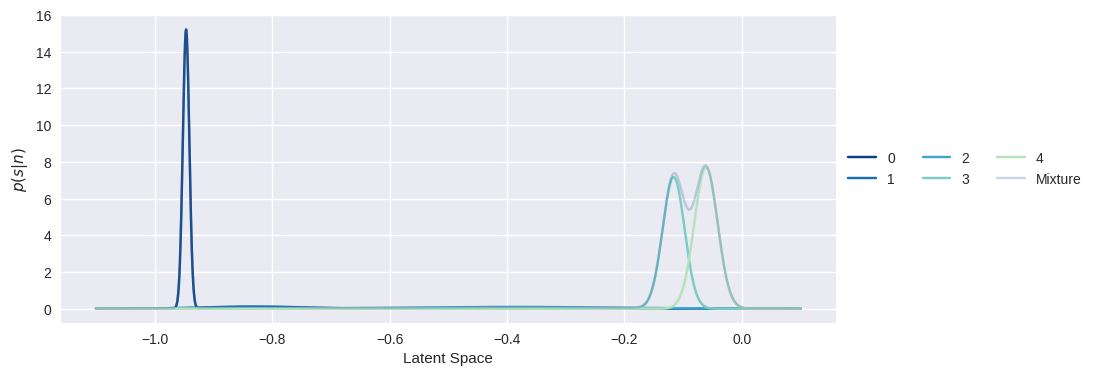

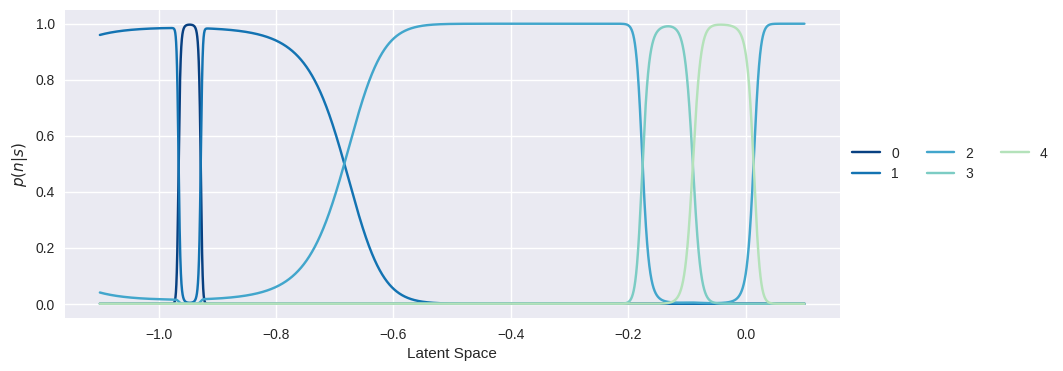

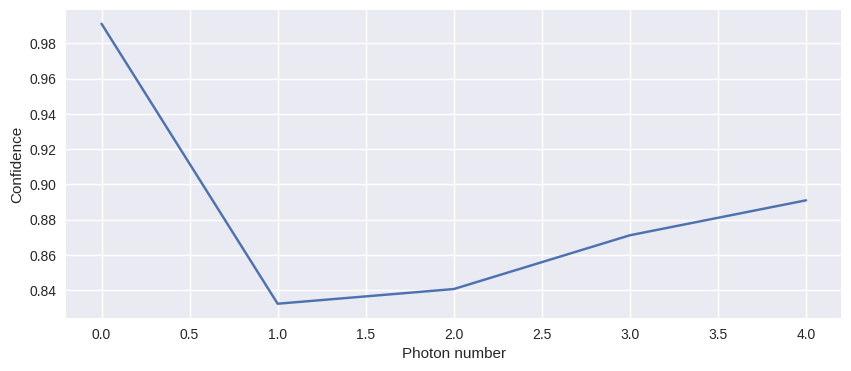

In [9]:
kd = gaussian_mixture(X_l_PCA, 
                    number_cluster=5,
                    flip = True)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

X_l_PCA = kd.normalize_latent(X_l_PCA, certain_clusters)

### Kernel PCA (Polynomial)

In [15]:
X_i_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)

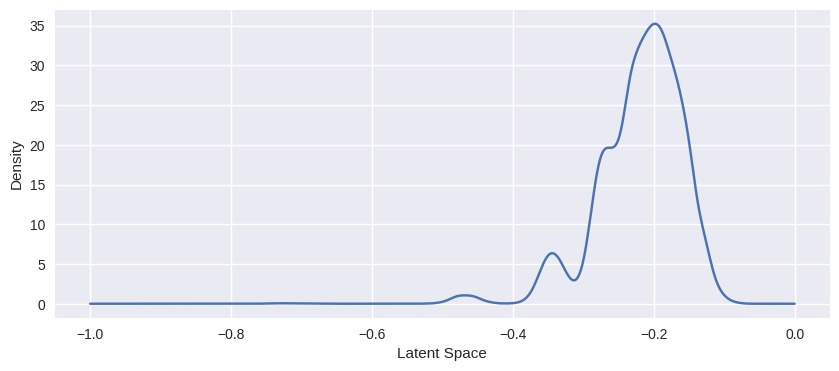

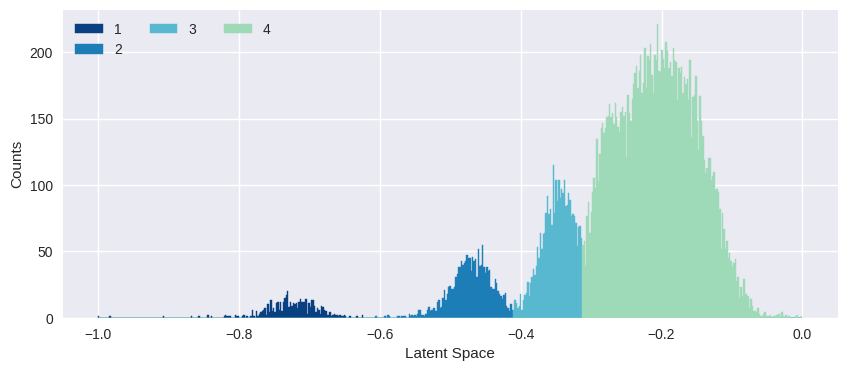

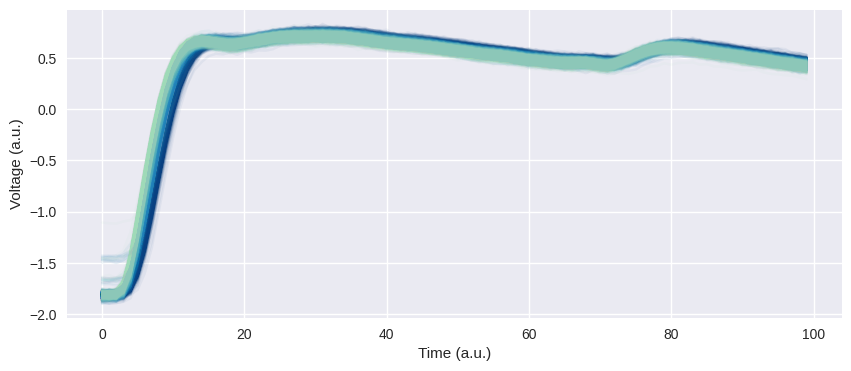

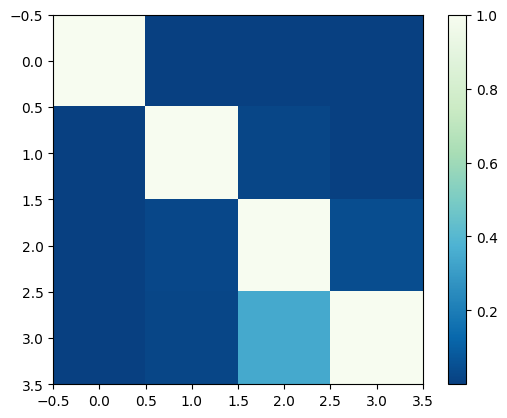

In [16]:
kd = density_gaussianMixture(X_l_KPCA_P, 
                                bw = [0.008],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_P = kd.normalize_latent(X_l_KPCA_P, certain_clusters)

### Kernel PCA (Radial basis function)

In [17]:
X_i_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)

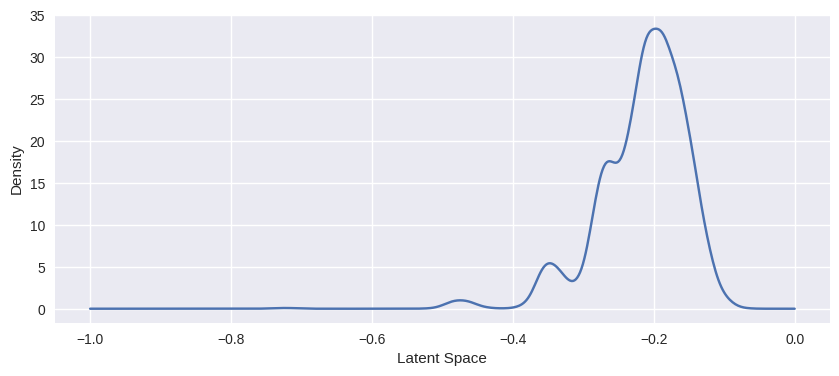

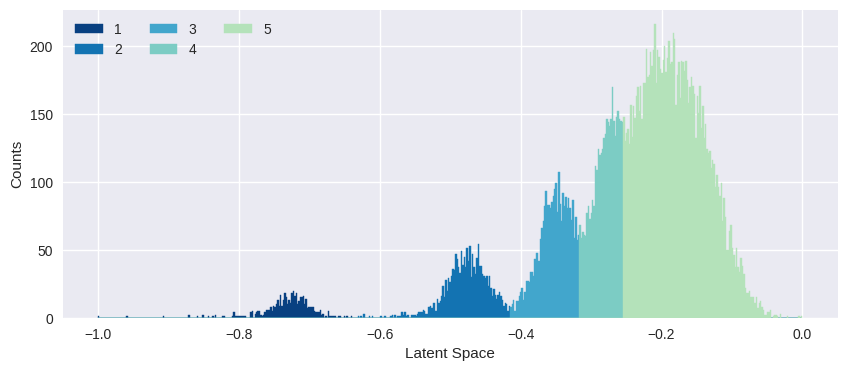

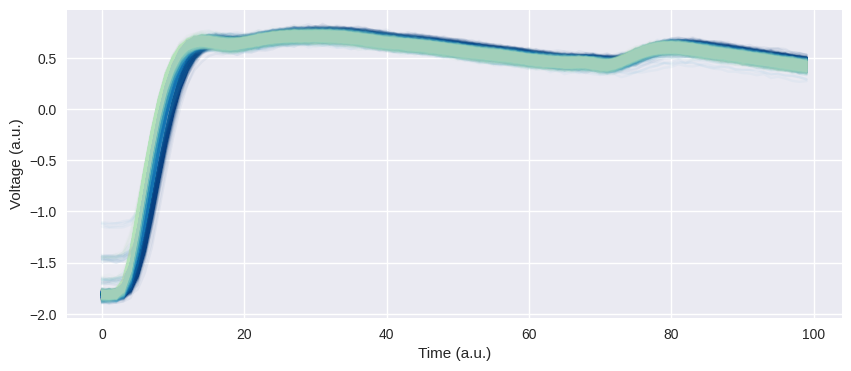

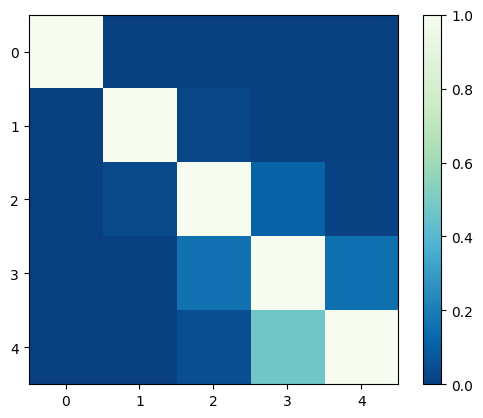

In [18]:
kd = density_gaussianMixture(X_l_KPCA_RBF, 
                                bw = [0.01],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_RBF = kd.normalize_latent(X_l_KPCA_RBF, certain_clusters)

### Kernel PCA (Sigmoid)

In [19]:
X_i_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)

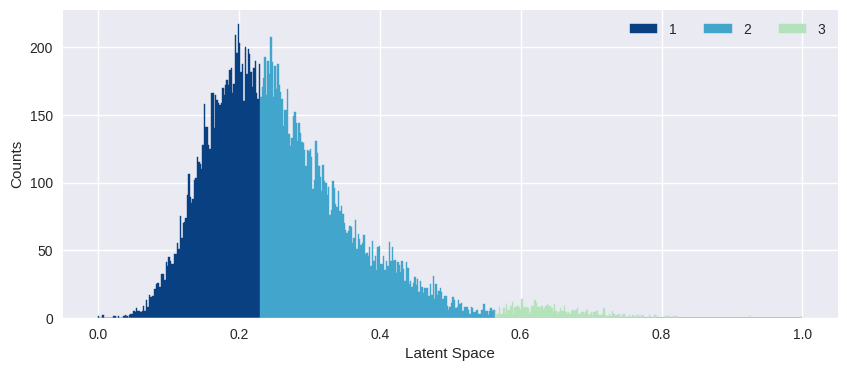

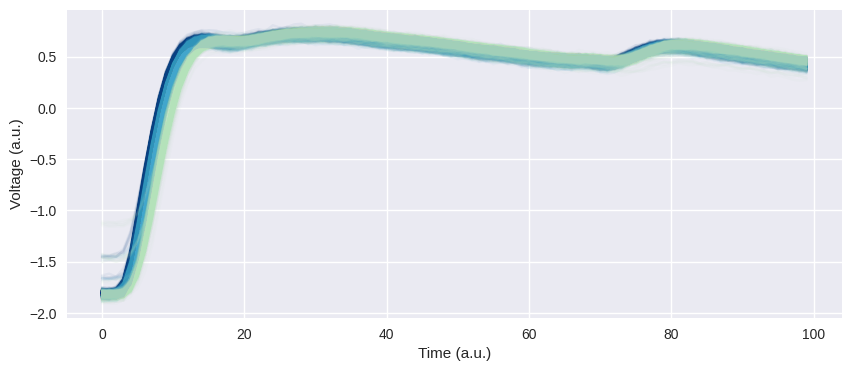

In [20]:
kd = density_gaussianMixture(X_l_KPCA_S, 
                                bw = [0.01],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
#kd.confidence(zeros)
X_l_KPCA_S = kd.normalize_latent(X_l_KPCA_S, certain_clusters)

### Kernel PCA (Cosine)

In [21]:
X_i_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)

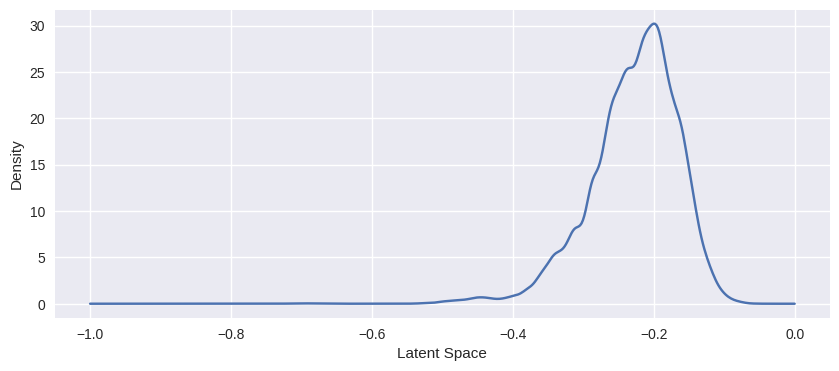

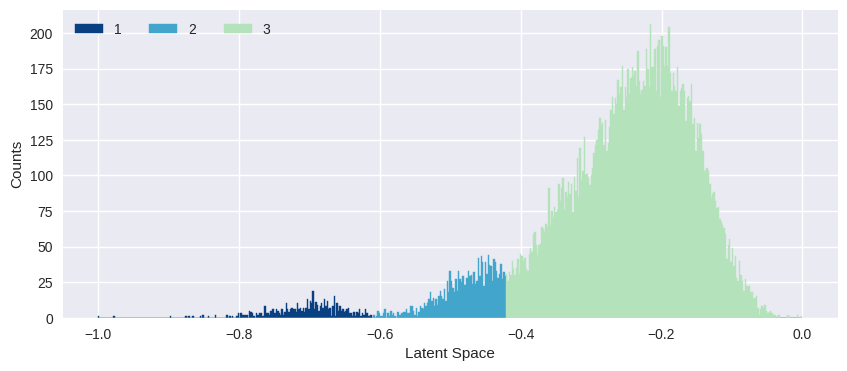

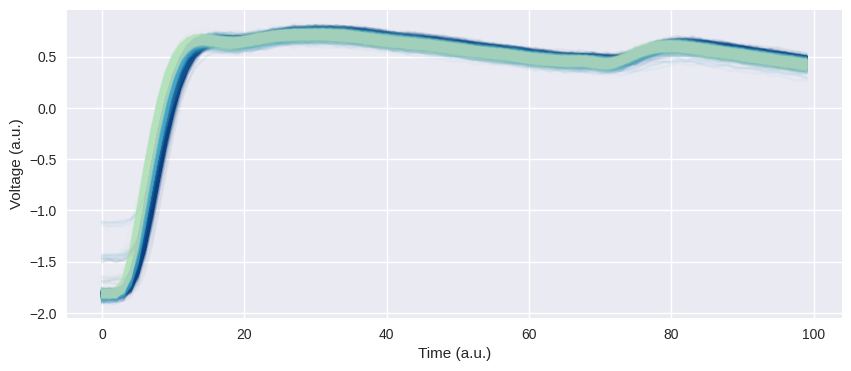

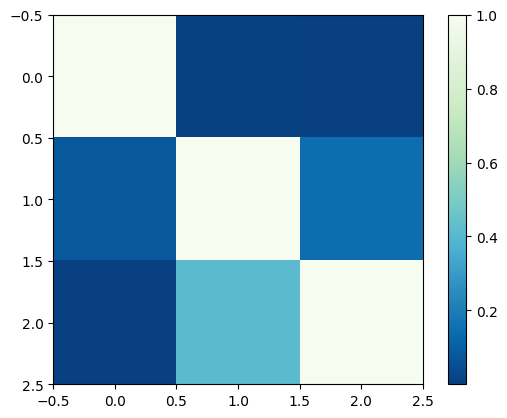

In [22]:
kd = density_gaussianMixture(X_l_KPCA_C, 
                                bw = [0.007],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_C = kd.normalize_latent(X_l_KPCA_C, certain_clusters)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [4]:
#data_train = (np.copy(X_train) -np.min(X_train)) / (np.max(X_train)-np.min(X_train)) 
#data_test = (np.copy(X_test) -np.min(X_test)) / (np.max(X_test)-np.min(X_test)) 

In [11]:
l = np.sqrt(len(X_test))
l

130.70577645995604

In [20]:
X_l1 = TSNE(n_components=2, perplexity=l).fit_transform(X_test)

In [24]:
method = PCA(n_components=1)
X_l2 = method.fit_transform(X_l1)

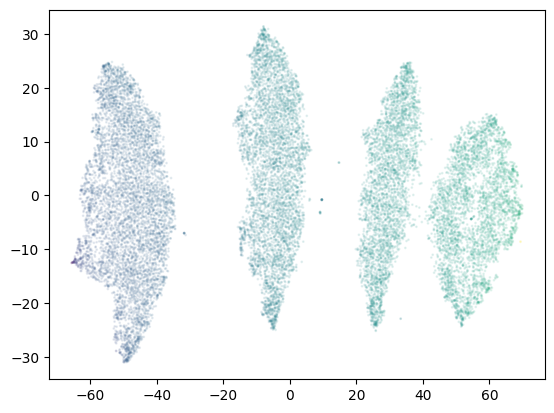

In [23]:
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(X_l2[:,0],X_l2[:,1], s=1, alpha=0.1, c=X_l_MAX)
plt.show()

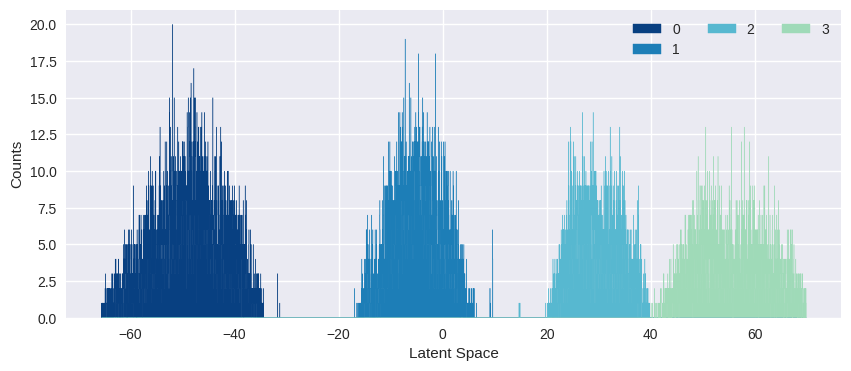

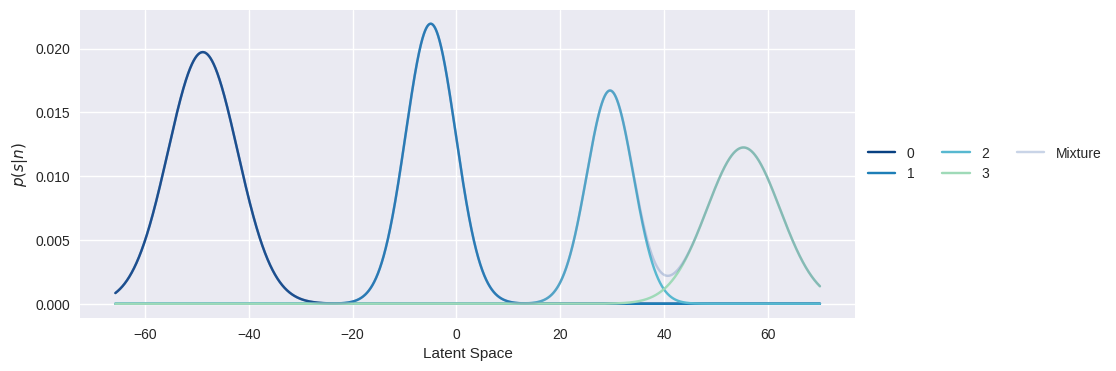

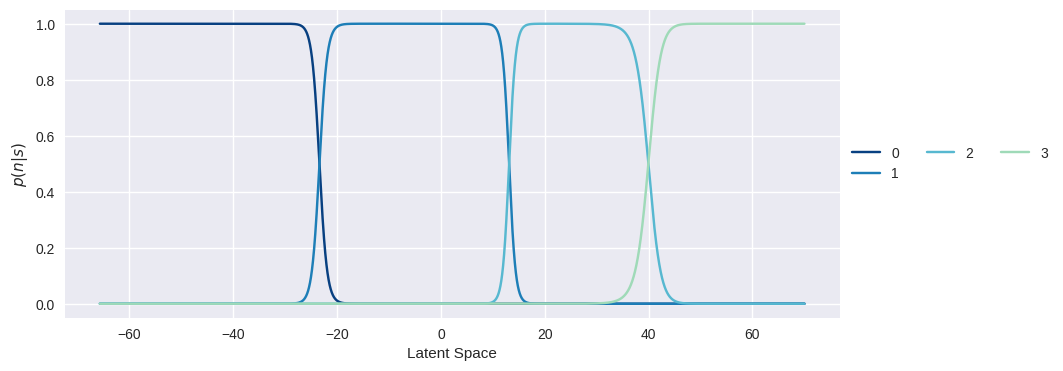

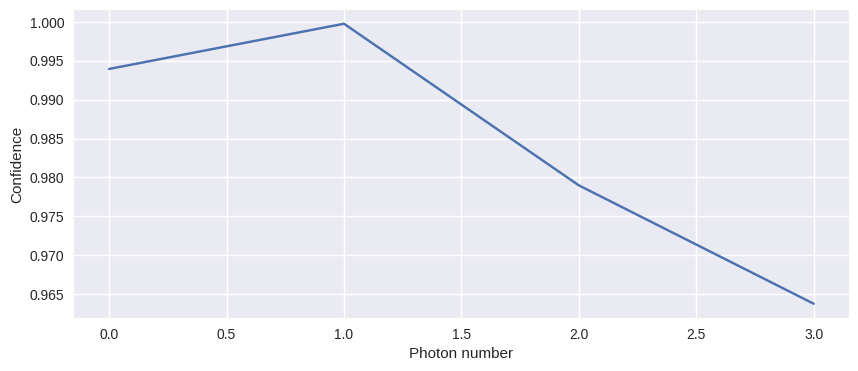

In [25]:
kd = gaussian_mixture(X_l2, 
                    number_cluster=4,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

In [ ]:
X_i_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,TSNE,n_components=1, perplexity=1000)

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:121: RuntimeWarning: invalid value encountered in sqrt
  mins[i] = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


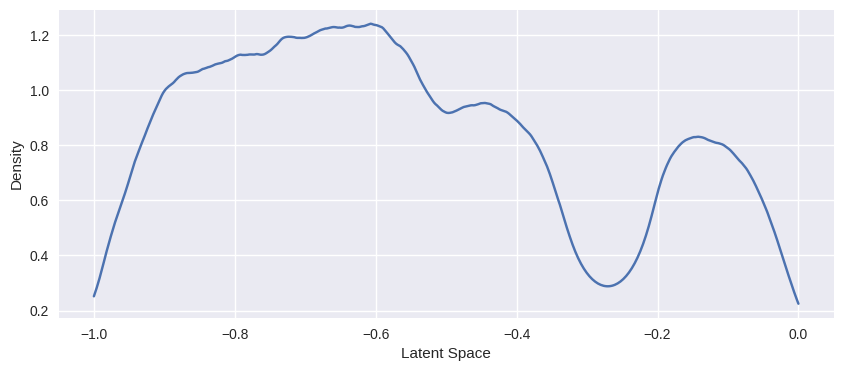

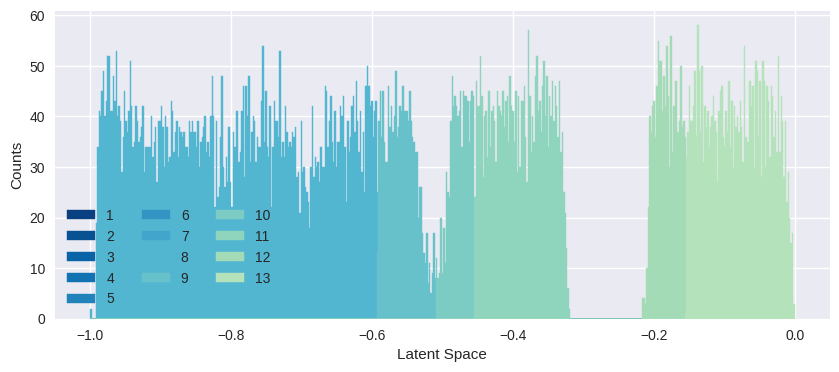

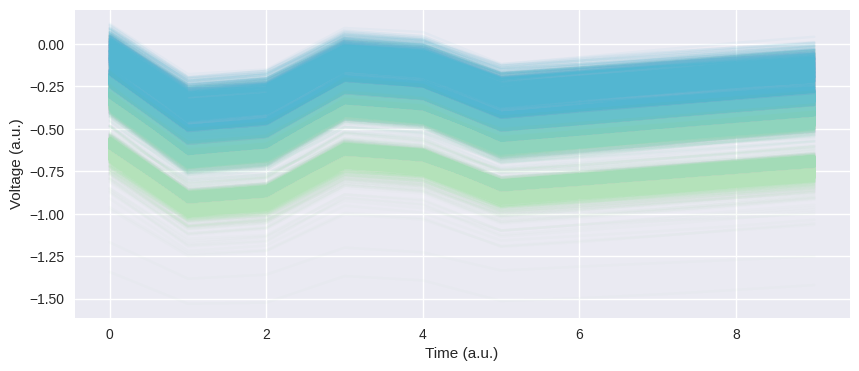

/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: divide by zero encountered in divide
  ret = um.true_divide(
/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


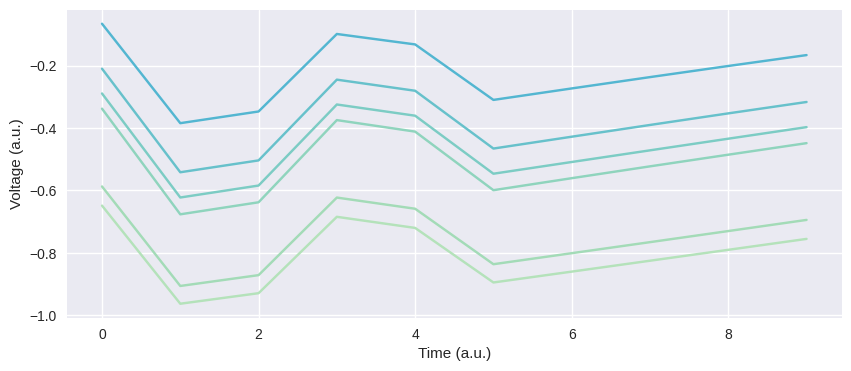

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:207: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:222: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


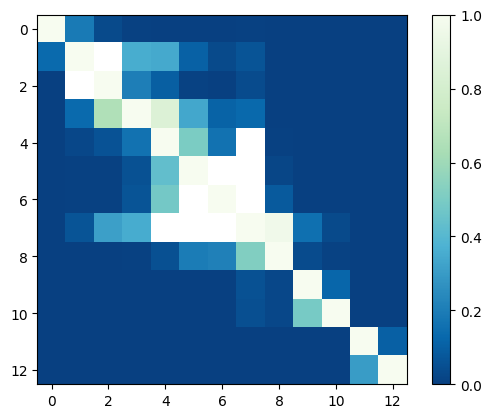

In [ ]:
kd = density_gaussianMixture(X_l_TSNE,
                                bw = [0.08],
                                min_cluster_prob = 0.02,
                                density_kernel='exponential',
                                bins_plot = 500,
                                flip = True, 
                                skip = 10)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_TSNE = kd.normalize_latent(X_l_TSNE, certain_clusters)

### Spectral Embedding 

In [25]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [26]:
X_i_NMF, X_l_NMF = dimension_reduction(2.1+np.copy(X_train),2.1+np.copy(X_test), path_save,NMF,n_components=1,alpha_W=0.1,random_state=42)

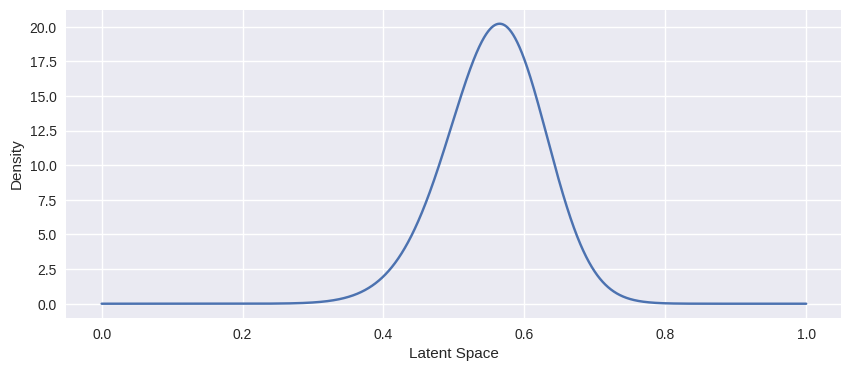

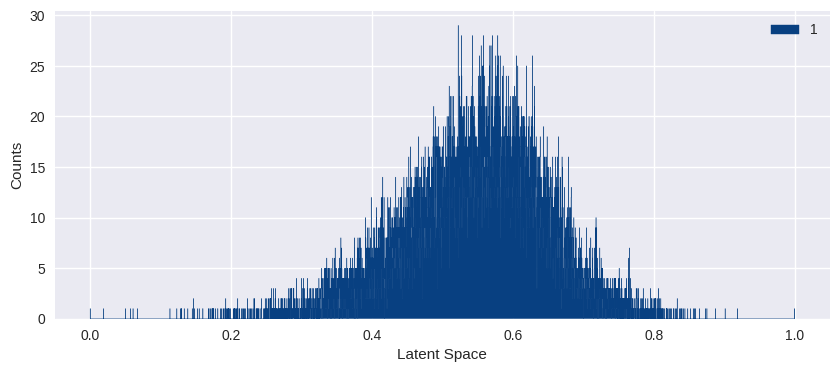

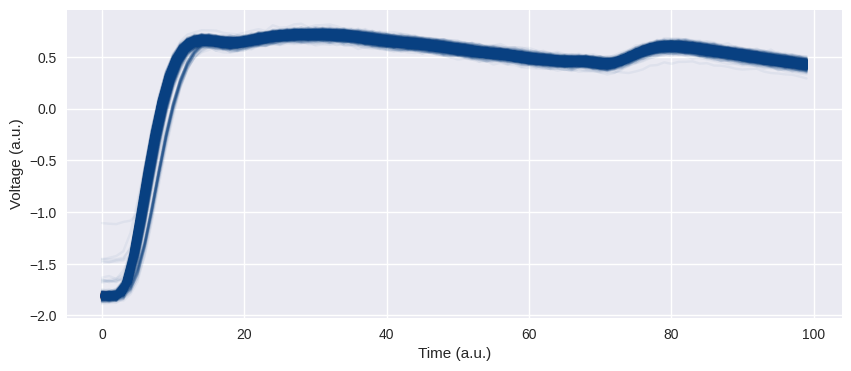

In [27]:
kd = density_gaussianMixture(X_l_NMF, 
                                bw = [0.05],
                                min_cluster_prob = 0.02,
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
X_l_NMF = kd.normalize_latent(X_l_NMF, certain_clusters)

### Isomap

In [9]:
X_i_ISO, X_l_ISO = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save, Isomap,n_neighbors=10, n_components=1, eigen_solver="arpack")

<Figure size 1000x400 with 0 Axes>

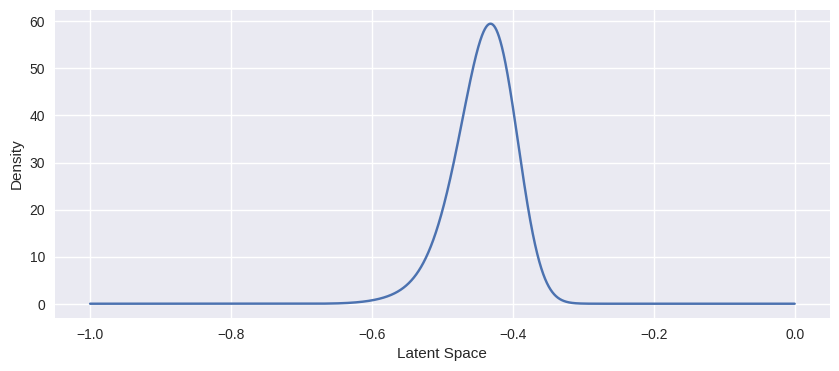

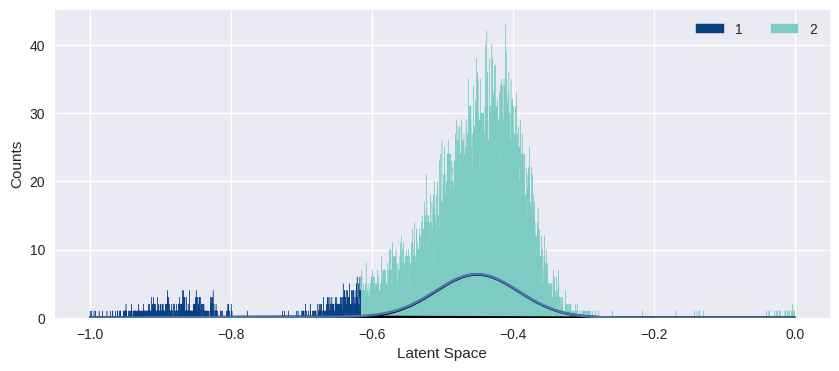

IndexError: boolean index did not match indexed array along dimension 0; dimension is 20712 but corresponding boolean dimension is 20708

In [10]:
kd = density_gaussianMixture(X_l_ISO, 
                                bw = [0.03],
                                min_cluster_prob = 0.015, 
                                bins_plot = 5000,
                                flip = True, 
                                skip = 10)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_ISO = kd.normalize_latent(X_l_ISO, certain_clusters)

### Autoencoder



In [38]:
X_i_AUTO, X_r_AUTO, X_l_AUTO  = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', filter=False, flip=True)

<Figure size 1000x400 with 0 Axes>

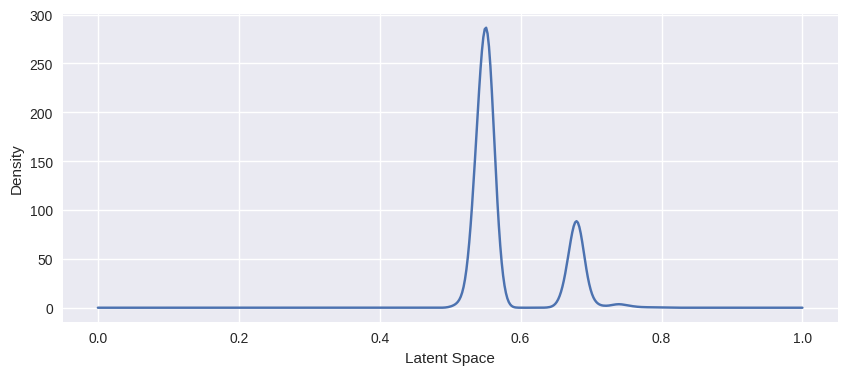

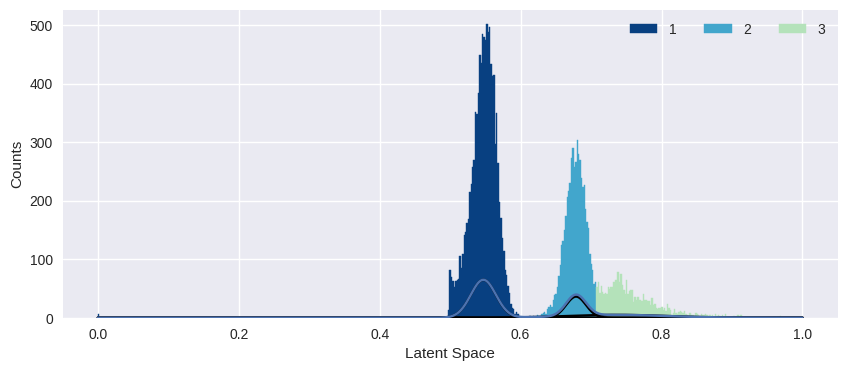

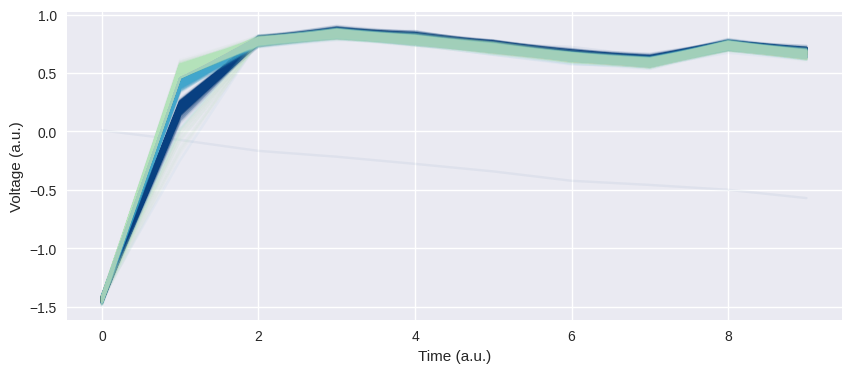

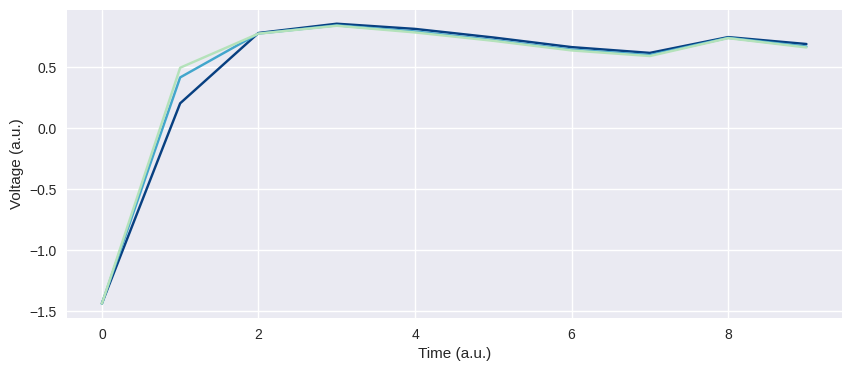

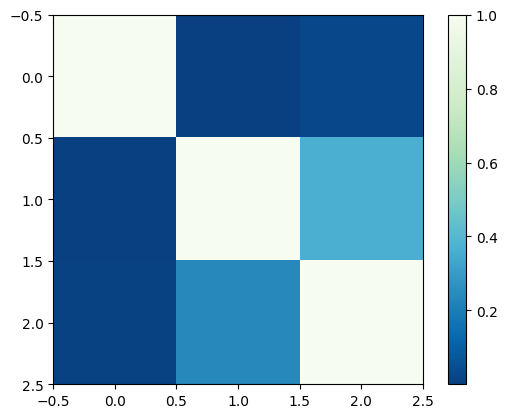

In [39]:
kd = density_gaussianMixture(X_l_AUTO,
                                bw = [0.009], 
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 10)
kd.plot_density()
kd.plot_cluster(5)
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTO = kd.normalize_latent(X_l_AUTO, certain_clusters)

In [15]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.004)

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:120: RuntimeWarning: invalid value encountered in sqrt
  mins[i] = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


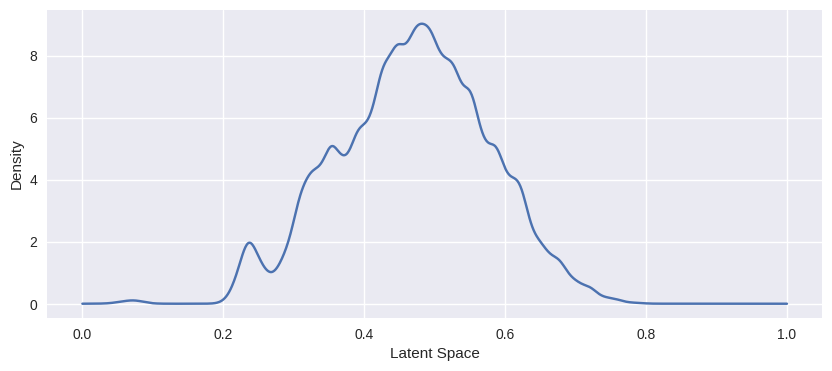

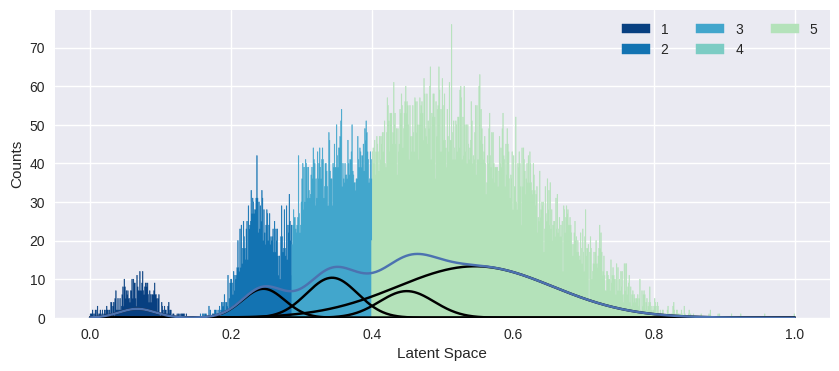

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:206: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:221: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


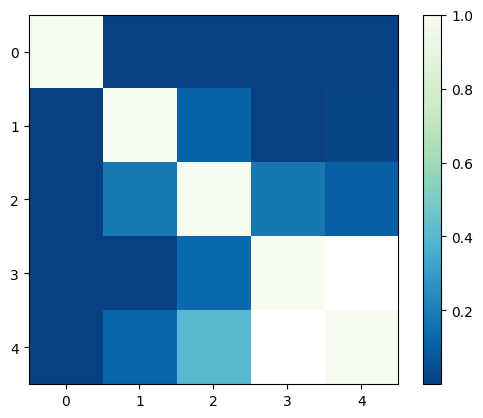

In [16]:
kd = density_gaussianMixture(X_l_AUTOF, 
                                bw = [0.009], 
                                min_cluster_prob = 0.01,
                                bins_plot = 1000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(6)
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTOF = kd.normalize_latent(X_l_AUTOF, certain_clusters)

In [34]:
i = [X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_C,  
     X_i_TSNE, X_i_ISO, 
     X_i_AUTO, X_i_AUTOF]
l = [X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_C,  
     X_l_TSNE, X_l_ISO, 
     X_l_AUTO, X_l_AUTOF]
methods = ['PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Cosine)', 
           't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
flip = [True, True, 
        True, True, 
        True, True, 
        False, True]
density_kernel = ['gaussian', 'gaussian', 
                  'gaussian', 'gaussian',  
                  'exponential', 'gaussian',
                  'gaussian', 'gaussian']
min_cluster_prob = [0.04, 0.04, 
                    0.04, 0.04,
                    0.04, 0.04, 
                    0.04, 0.04]
bw = [0.03, 0.024, 
      0.016, 0.018,
      0.03, 0.03, 
      0.018, 0.015]

comp = compare(flip, min_cluster_prob, density_kernel, bw)
#score = comp.quality_metric_plot(i,l,methods, 4)